# Nemotron activation-distribution analysis

This notebook analyzes semantic activation categories saved by `activation_distribution.py`: token embeddings; FFN input, pre-activation, hidden, and output; attention input, Q/K/V, context, and output; Mamba input, projected, hidden, and output; final hidden states; and logits. Distribution parameters are fit by maximum likelihood, with fit plotting provided by `histogram.py`.

Generate or refresh the artifact by running `activation_distribution.py` before this notebook. Artifact format 2 is required; older files grouped unrelated linear layers together and must be regenerated.

In [1]:
from pathlib import Path
import sys
import torch
from IPython.display import Markdown, display
def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "llm_analysis" / "activation_distribution.py").exists():
            return candidate / "llm_analysis"
    raise FileNotFoundError("Could not locate the llm_analysis project root")
PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from histogram import (
    DEFAULT_BULK_MASS,
    fit_histogram_distributions,
    plot_histogram_fits,
)
RESULTS_PATH = PROJECT_ROOT / "activation_distribution_results.pt"
RESULTS_PATH


PosixPath('/home/bubbles/Documents/bitsparse/nemotron/activation_distribution_results.pt')

In [2]:
if not RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"{RESULTS_PATH} does not exist. Run activation_distribution.py first."
    )

results = torch.load(RESULTS_PATH, map_location="cpu", weights_only=True)
histograms = results["histograms"]
edges = results["edges"]
extrema = results["extrema"]
category_specs = results["categories"]

metadata = {
    key: results[key]
    for key in (
        "model_name",
        "num_batches",
        "sequence_length",
        "sequences_per_batch",
        "bin_width",
        "limit",
    )
}
metadata

{'model_name': 'nvidia/Nemotron-H-8B-Base-8K',
 'num_batches': 4,
 'sequence_length': 1024,
 'sequences_per_batch': 1,
 'bin_width': 0.05,
 'limit': 150.0}

In [3]:
if set(histograms) != set(extrema) or set(histograms) != set(category_specs):
    raise ValueError("Histogram, extrema, and category labels do not match")
if any(counts.numel() != edges.numel() + 1 for counts in histograms.values()):
    raise ValueError("Histogram counts are incompatible with the saved bin edges")

summary_rows = []
for label, counts in histograms.items():
    minimum, maximum = extrema[label]
    spec = category_specs[label]
    module_path = spec["module_path"] or "<module>"
    capture_point = f'{spec["parent_type"]}.{module_path} {spec["capture"]}'
    total = int(counts.sum())
    overflow = int(counts[0] + counts[-1])
    summary_rows.append(
        (
            label,
            capture_point,
            f"{total:,}",
            f"{minimum.item():.6g}",
            f"{maximum.item():.6g}",
            f"{overflow / total:.3%}",
        )
    )

def show_table(headers, rows):
    header = "| " + " | ".join(headers) + " |"
    divider = "| " + " | ".join("---" for _ in headers) + " |"
    body = ["| " + " | ".join(map(str, row)) + " |" for row in rows]
    display(Markdown("\n".join((header, divider, *body))))

show_table(
    (
        "Activation category",
        "Capture point",
        "Observations",
        "Minimum",
        "Maximum",
        "Outside fit range",
    ),
    summary_rows,
)

| Activation category | Capture point | Observations | Minimum | Maximum | Outside fit range |
| --- | --- | --- | --- | --- | --- |
| Token embeddings | NemotronHForCausalLM.model.embeddings output | 16,777,216 | -0.196289 | 0.167969 | 0.000% |
| FFN input | NemotronHMLP.<module> input | 402,653,184 | -66 | 160 | 0.000% |
| FFN pre-activation | NemotronHMLP.up_proj output | 2,113,929,216 | -36.75 | 104.5 | 0.000% |
| FFN hidden | NemotronHMLP.down_proj input | 2,113,929,216 | 0 | 10944 | 0.000% |
| FFN output | NemotronHMLP.<module> output | 402,653,184 | -2032 | 1488 | 0.001% |
| Attention input | NemotronHAttention.<module> input | 67,108,864 | -55.5 | 109.5 | 0.000% |
| Attention query | NemotronHAttention.q_proj output | 67,108,864 | -16.5 | 14.6875 | 0.000% |
| Attention key | NemotronHAttention.k_proj output | 16,777,216 | -41.25 | 29.75 | 0.000% |
| Attention value | NemotronHAttention.v_proj output | 16,777,216 | -19.625 | 29.5 | 0.000% |
| Attention context | NemotronHAttention.o_proj input | 67,108,864 | -16.625 | 20.25 | 0.000% |
| Attention output | NemotronHAttention.<module> output | 67,108,864 | -104 | 88 | 0.000% |
| Mamba input | NemotronHMamba2Mixer.<module> input | 402,653,184 | -49 | 84 | 0.000% |
| Mamba projected | NemotronHMamba2Mixer.in_proj output | 1,824,522,240 | -65 | 59.75 | 0.000% |
| Mamba hidden | NemotronHMamba2Mixer.out_proj input | 805,306,368 | -378 | 640 | 0.000% |
| Mamba output | NemotronHMamba2Mixer.<module> output | 402,653,184 | -330 | 888 | 0.001% |
| Final hidden | NemotronHForCausalLM.model.norm_f output | 16,777,216 | -234 | 262 | 0.008% |
| Logits | NemotronHForCausalLM.lm_head output | 536,870,912 | -123.5 | 368 | 0.000% |

In [4]:
# Adjust the central-mass/tail split or show every candidate fit as needed.
bulk_mass = DEFAULT_BULK_MASS
show_all_candidates = False
fits = fit_histogram_distributions(histograms, edges, bulk_mass=bulk_mass)

fit_rows = []
for label, regions in fits.items():
    for region in ("bulk", "tail"):
        candidates = regions.get(region, [])
        if not candidates:
            fit_rows.append(
                (label, region, "-", "not fitted", "-", "-", "-", "<3 populated bins")
            )
            continue
        for rank, fit in enumerate(candidates, start=1):
            if rank > 1 and not show_all_candidates:
                continue
            fit_rows.append(
                (
                    label,
                    region,
                    rank,
                    fit.family,
                    f"{fit.log_likelihood:.4g}",
                    f"{fit.log_rmse:.4f}",
                    f"{fit.r_squared:.4f}",
                    fit.parameters,
                )
            )

show_table(
    (
        "Activation category",
        "Region",
        "Rank",
        "Family",
        "Log-likelihood",
        "log-RMSE",
        "R²",
        "Parameters",
    ),
    fit_rows,
)

| Activation category | Region | Rank | Family | Log-likelihood | log-RMSE | R² | Parameters |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Token embeddings | bulk | 1 | polynomial | 4.962e+07 | 2.2154 | 0.2117 | mu=-0.025, scale=0.0007424, exponent=1.001 |
| Token embeddings | tail | 1 | gaussian | 1.043e+04 | 1.0737 | 0.6579 | mu=-0.025, sigma=0.08412 |
| FFN input | bulk | 1 | polynomial | -3.175e+08 | 0.0977 | 0.9961 | mu=0.025, scale=0.4531, exponent=2.27 |
| FFN input | tail | 1 | polynomial | -3.382e+07 | 0.2792 | 0.9980 | mu=0.025, scale=0.3791, exponent=4.221 |
| FFN pre-activation | bulk | 1 | polynomial | -2.934e+09 | 0.6395 | 0.9147 | mu=-0.675, scale=1.531, exponent=3.041 |
| FFN pre-activation | tail | 1 | exponential | -1.746e+08 | 0.9319 | 0.9888 | mu=-0.675, scale=0.9809 |
| FFN hidden | bulk | - | not fitted | - | - | - | <3 populated bins |
| FFN hidden | tail | 1 | polynomial | -7.677e+07 | 0.9187 | 0.9778 | mu=0.025, scale=0.2954, exponent=2.202 |
| FFN output | bulk | 1 | polynomial | 1.802e+09 | 15.4838 | -34.5407 | mu=0.025, scale=2.201e-18, exponent=1 |
| FFN output | tail | 1 | polynomial | -3.962e+07 | 0.3306 | 0.9967 | mu=0.025, scale=1.007, exponent=4.303 |
| Attention input | bulk | 1 | exponential | -5.575e+07 | 0.0809 | 0.9938 | mu=0.025, scale=0.5362 |
| Attention input | tail | 1 | polynomial | -6.276e+06 | 0.3371 | 0.9957 | mu=0.025, scale=0.1465, exponent=3.285 |
| Attention query | bulk | 1 | gaussian | -8.219e+07 | 0.0857 | 0.9901 | mu=-0.025, sigma=0.9238 |
| Attention query | tail | 1 | polynomial | -6.212e+06 | 0.2538 | 0.9957 | mu=-0.025, scale=9.181, exponent=11.58 |
| Attention key | bulk | 1 | exponential | -3.501e+07 | 0.1433 | 0.9786 | mu=0.025, scale=2.052 |
| Attention key | tail | 1 | polynomial | -2.415e+06 | 0.4616 | 0.9466 | mu=0.025, scale=5.813, exponent=5.389 |
| Attention value | bulk | 1 | polynomial | -1.746e+07 | 0.1091 | 0.9961 | mu=0.025, scale=0.605, exponent=2.395 |
| Attention value | tail | 1 | polynomial | -1.736e+06 | 0.2363 | 0.9964 | mu=0.025, scale=156.1, exponent=108.6 |
| Attention context | bulk | 1 | polynomial | 2.633e+08 | 10.3136 | -24.6940 | mu=0.025, scale=5.212e-12, exponent=1 |
| Attention context | tail | 1 | polynomial | -3.11e+06 | 0.1028 | 0.9998 | mu=0.025, scale=1.3, exponent=6.14 |
| Attention output | bulk | 1 | polynomial | 3.235e+08 | 12.6506 | -38.0022 | mu=0.025, scale=3.24e-14, exponent=1 |
| Attention output | tail | 1 | polynomial | -3.143e+06 | 0.3689 | 0.9980 | mu=0.025, scale=1.424, exponent=6.314 |
| Mamba input | bulk | 1 | exponential | -3.167e+08 | 0.1172 | 0.9809 | mu=0.025, scale=0.5632 |
| Mamba input | tail | 1 | polynomial | -2.953e+07 | 0.2073 | 0.9990 | mu=0.025, scale=8.73e-09, exponent=3.619 |
| Mamba projected | bulk | 1 | exponential | -2.156e+09 | 0.0940 | 0.9936 | mu=-0.075, scale=0.7364 |
| Mamba projected | tail | 1 | polynomial | -1.8e+08 | 0.4290 | 0.9960 | mu=-0.075, scale=20.48, exponent=19.09 |
| Mamba hidden | bulk | 1 | polynomial | 7.539e+09 | 19.4635 | -42.8456 | mu=0.025, scale=1.523e-18, exponent=1 |
| Mamba hidden | tail | 1 | polynomial | -8.665e+07 | 0.2614 | 0.9976 | mu=0.025, scale=0.5692, exponent=2.669 |
| Mamba output | bulk | 1 | polynomial | 1.081e+09 | 9.2043 | -8.6020 | mu=0.025, scale=1.667e-11, exponent=1 |
| Mamba output | tail | 1 | polynomial | -5.047e+07 | 0.2727 | 0.9964 | mu=0.025, scale=2.279, exponent=3.806 |
| Final hidden | bulk | 1 | gaussian | -3.973e+07 | 0.1595 | 0.9504 | mu=-0.025, sigma=3.208 |
| Final hidden | tail | 1 | polynomial | -2.773e+06 | 0.8228 | 0.9019 | mu=-0.025, scale=5.338e-09, exponent=3.224 |
| Logits | bulk | 1 | gaussian | -1.195e+09 | 0.1889 | 0.9238 | mu=-1.425, sigma=2.814 |
| Logits | tail | 1 | polynomial | -8.047e+07 | 1.3225 | 0.9268 | mu=-1.425, scale=5.736e-09, exponent=3.46 |

## FFN

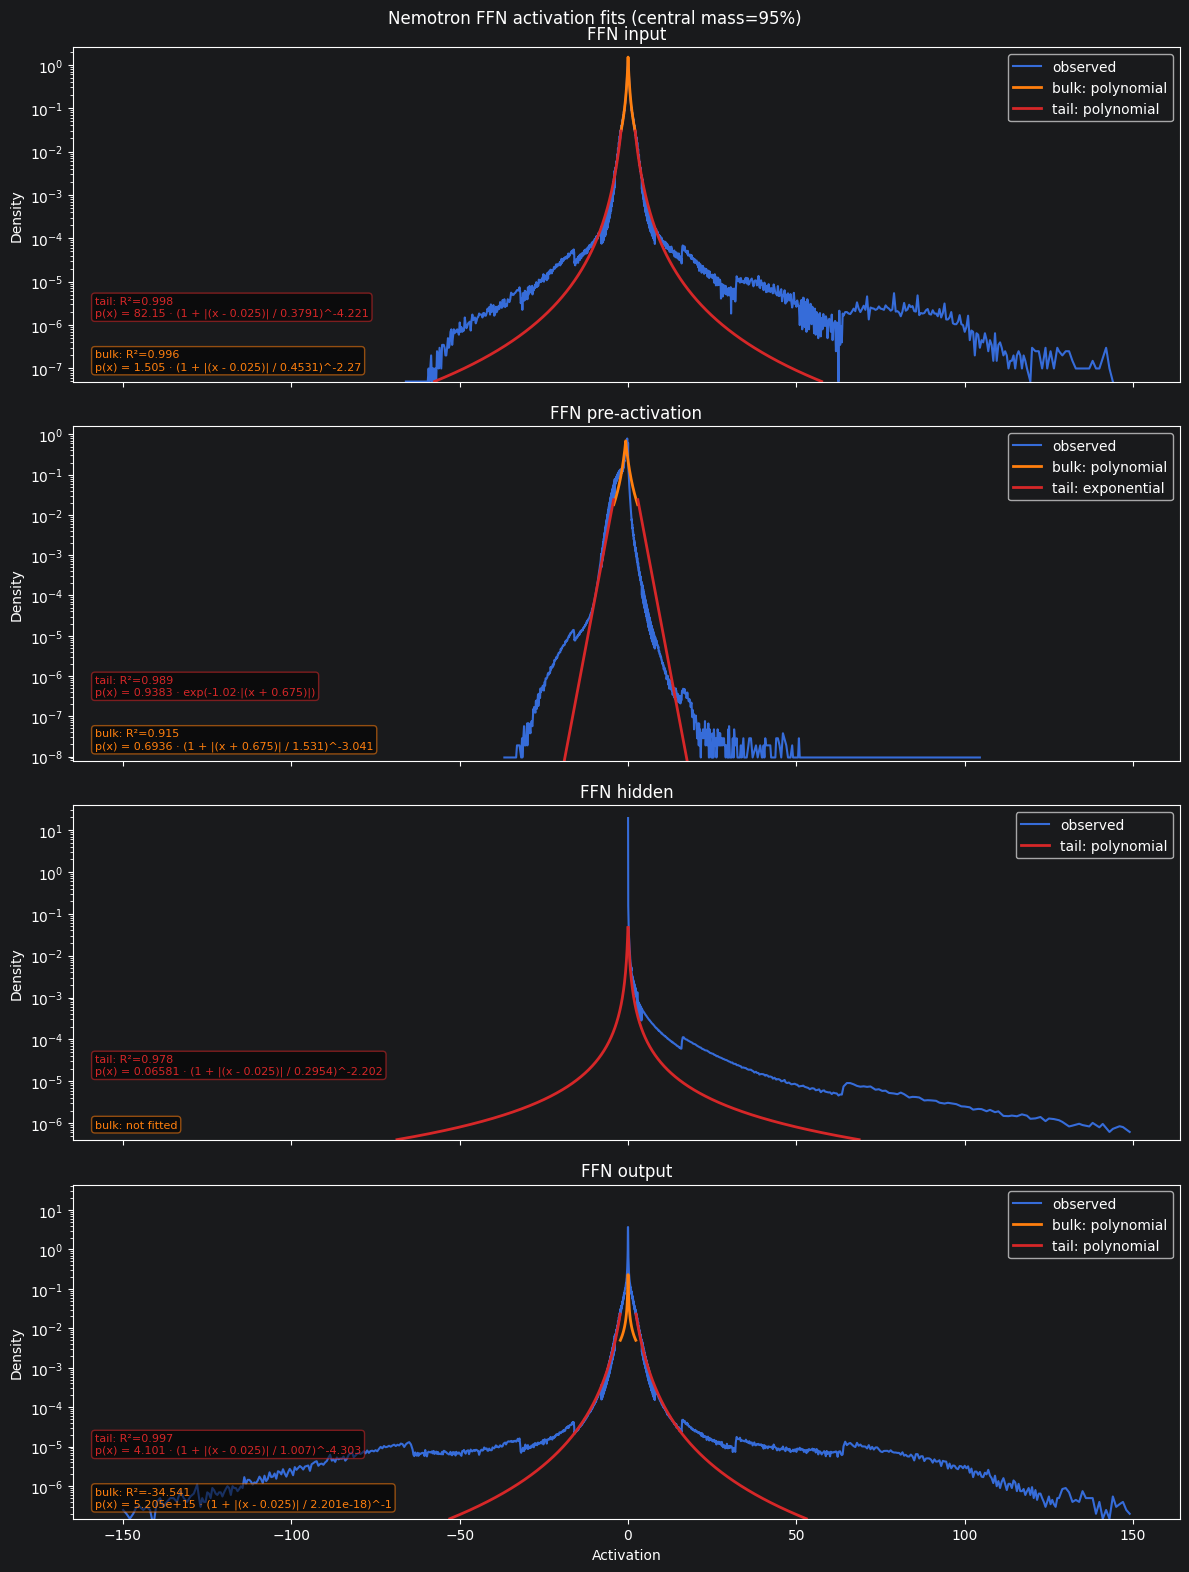

## Attention

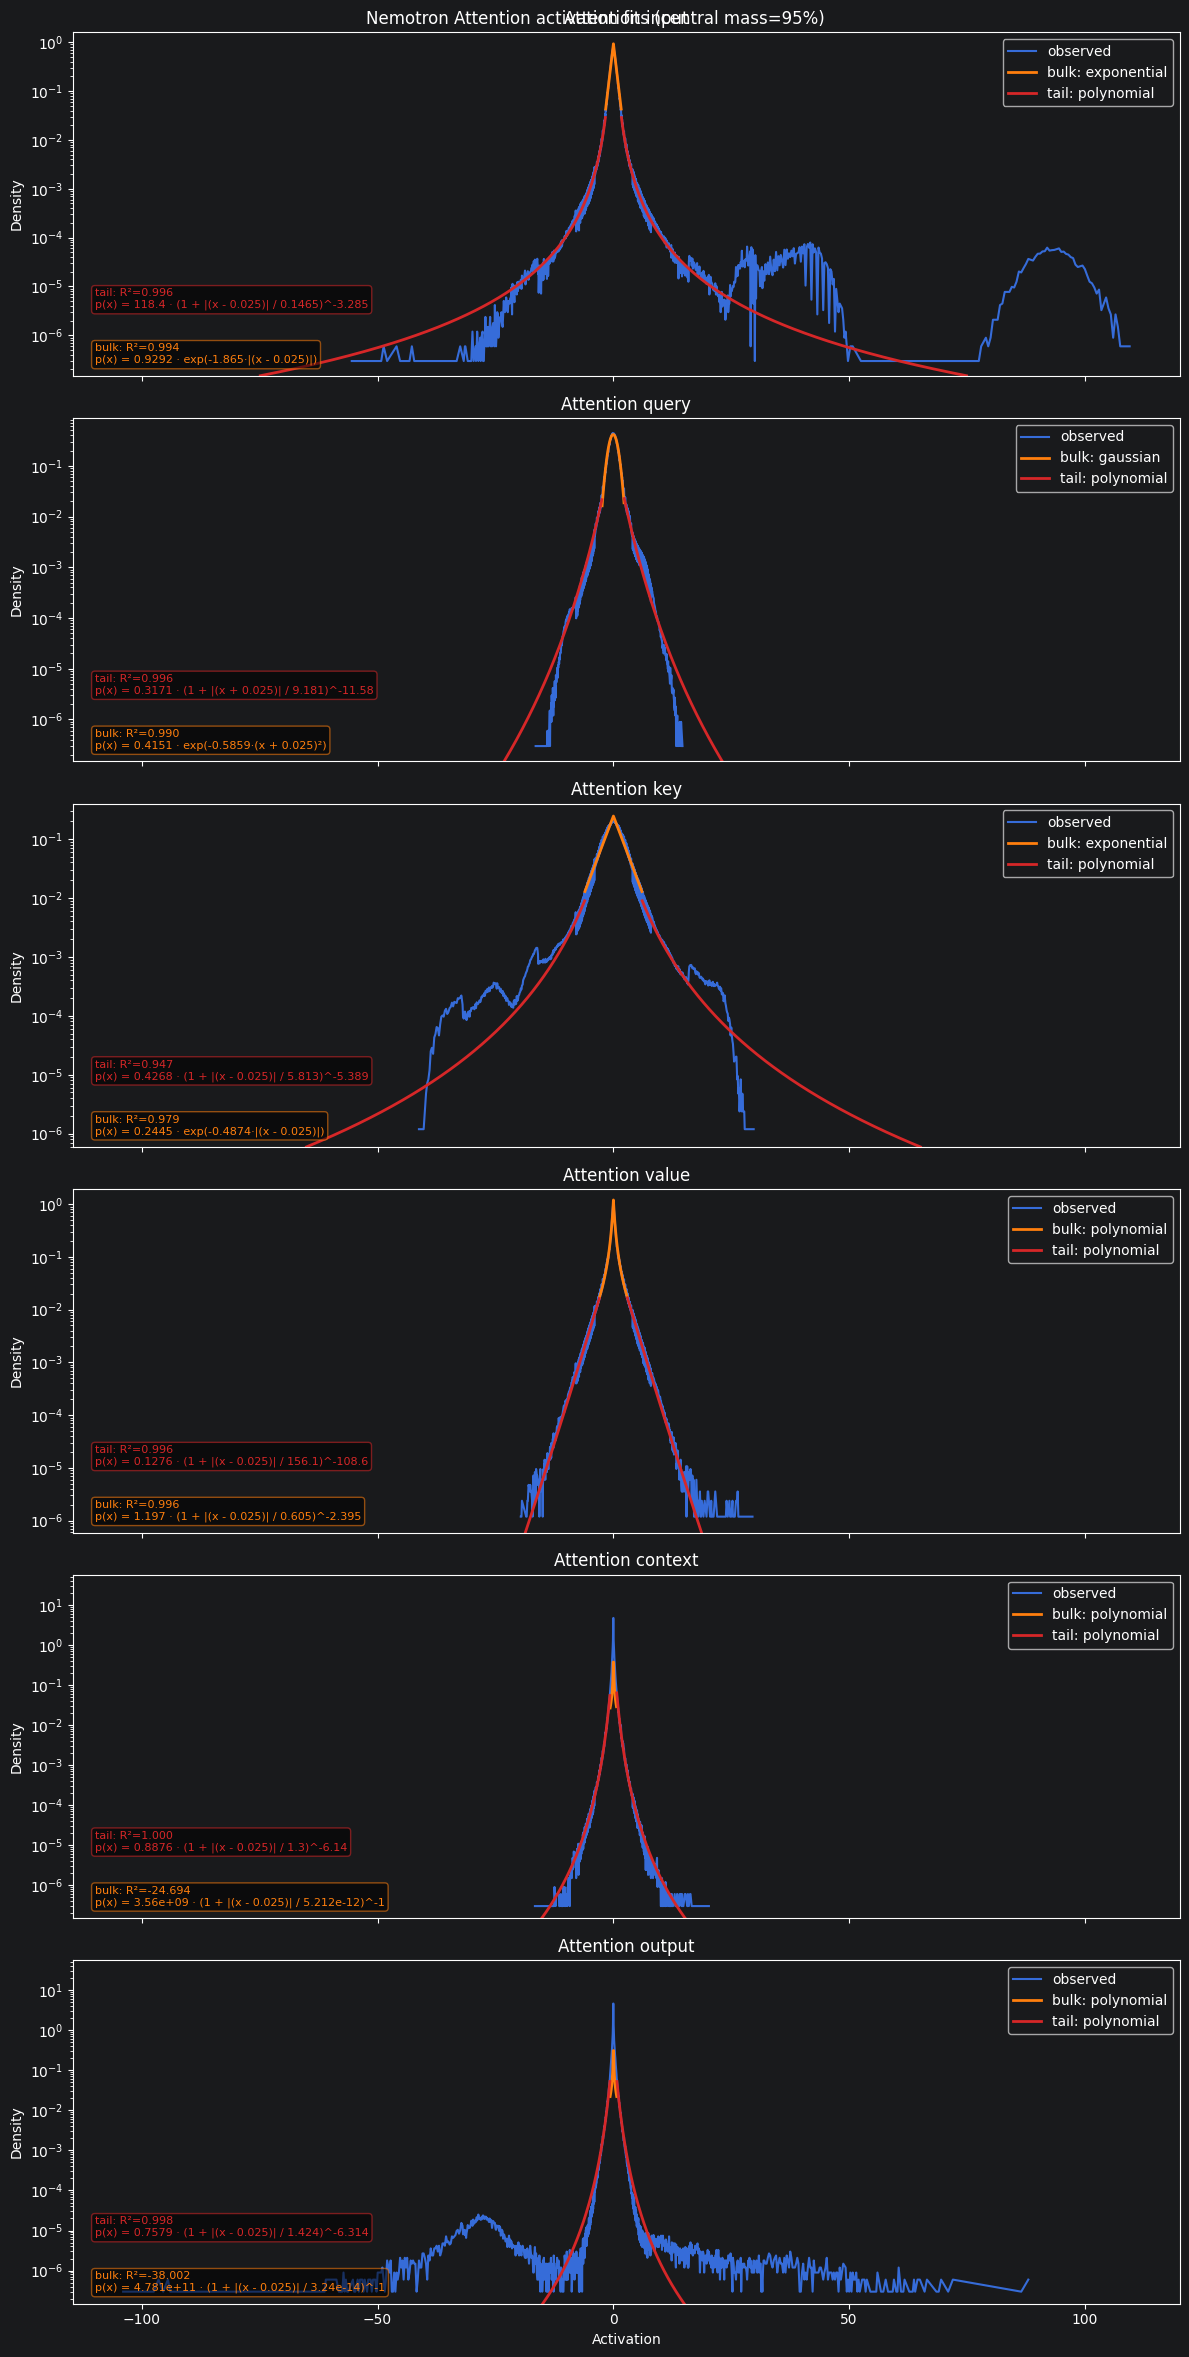

## Mamba

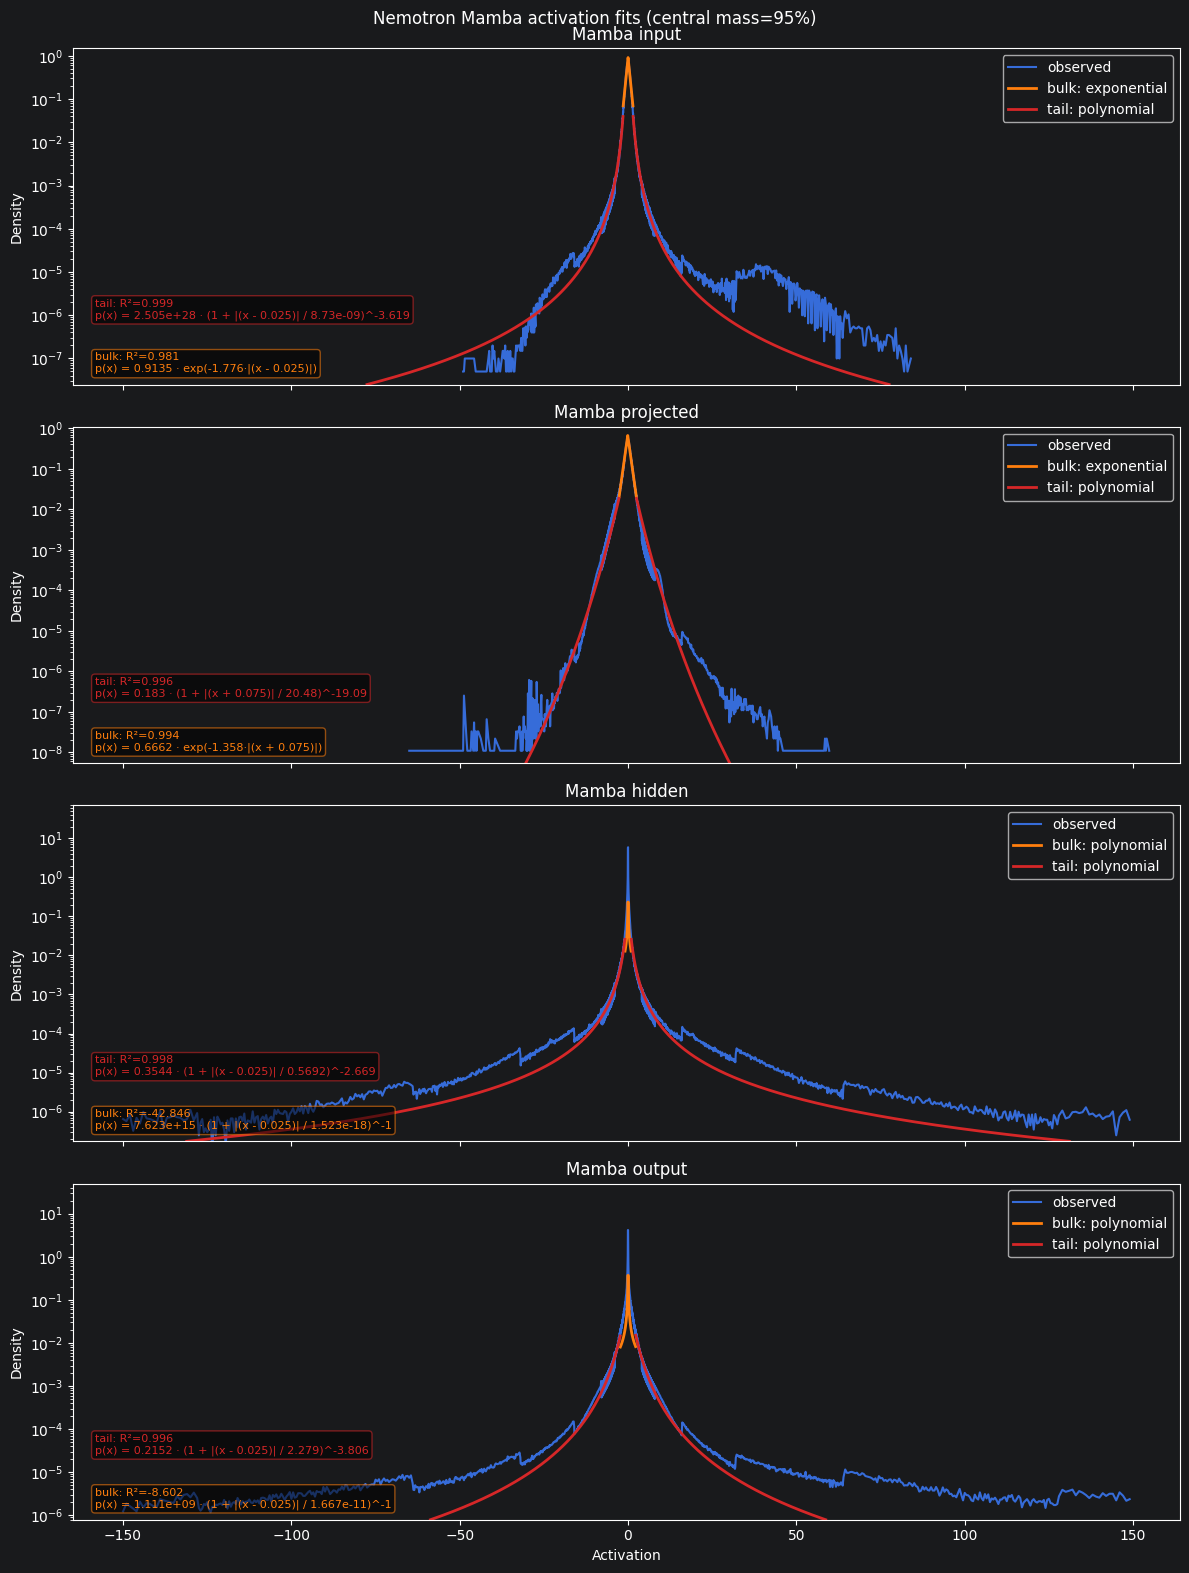

## Other

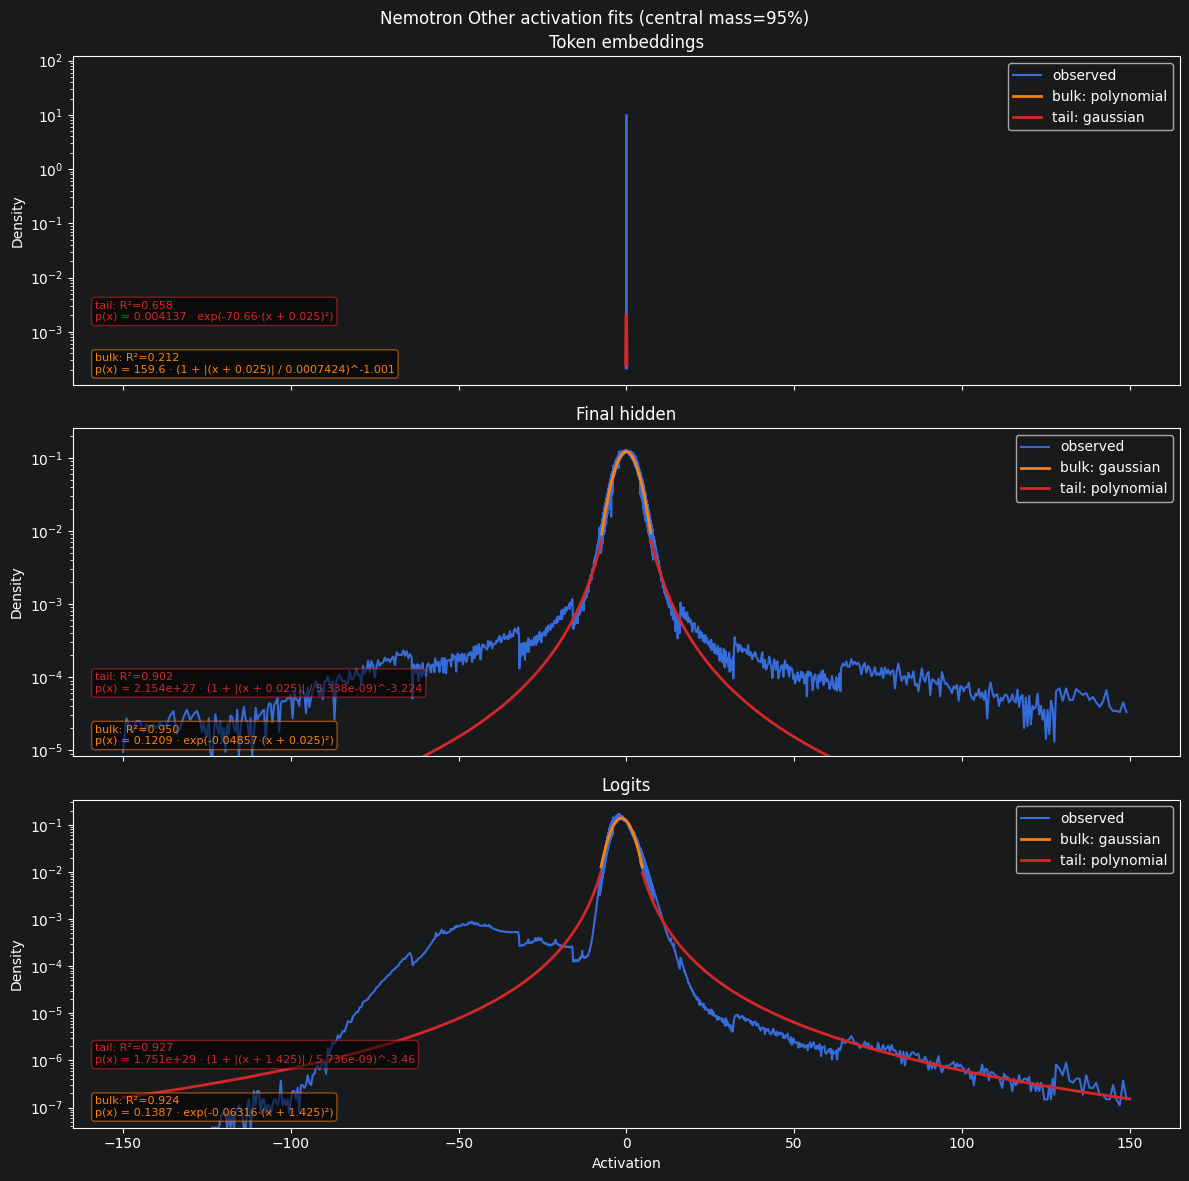

In [5]:
plot_groups = {
    "FFN": [label for label in histograms if label.startswith("FFN ")],
    "Attention": [label for label in histograms if label.startswith("Attention ")],
    "Mamba": [label for label in histograms if label.startswith("Mamba ")],
    "Other": [
        label
        for label in histograms
        if not label.startswith(("FFN ", "Attention ", "Mamba "))
    ],
}

for group, labels in plot_groups.items():
    if not labels:
        continue
    display(Markdown(f"## {group}"))
    plot_histogram_fits(
        {label: histograms[label] for label in labels},
        edges,
        {label: fits[label] for label in labels},
        bulk_mass=bulk_mass,
        title=f"Nemotron {group} activation fits",
        x_label="Activation",
    )